In [2]:
# === Standard Library Imports ===
import numpy as np
import pandas as pd
import h5py
from tqdm import tqdm

# === ML/Stats Imports ===
import torch
from sklearn.metrics import roc_auc_score, r2_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr, spearmanr, norm

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns

# === Local Imports ===
import config
from src.models import get_model_and_tokenizer
from src import utils

/home/zy2559/.conda/envs/torch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
# === Model Configuration ===
MODEL_NAME = 'llama-70b-3.3'
LAYER_NAME = 'layer_33'
LAYER_IDX = 33
FEATURE_TYPE = 'average'

# === Analysis Settings ===
SHOW_VALUES = 'avg_auroc'  # Options: avg_max_acc, avg_control_acc, avg_auroc
USE_SCALER = True

# === Probe Lists ===
# List of probe names to load and analyze
PROBE_LISTS = [
    'claims__definitional_gemini_600_full_average', 
    'claims__evidential_gemini_600_full_average', 
    'claims__fictional_gemini_600_full_average',
    'claims__logical_gemini_600_full_average', 
    'ethics__commonsense_average',
    'sycophancy__mmlu_stem_same_conf_all_average',
    'repe_honesty__IF_dishonest_average',
    'combined__claims_gemini600_ethical_sycosameconf_IFdishonest_RP_IT_SB_average'
]

# === Training Settings ===
# Per-dataset settings for training probes
TRAIN_SETTINGS = {
    'claims__definitional_gemini_600_full': {'feature_type': 'average', 'probe_type': 'lr'},
    'claims__evidential_gemini_600_full': {'feature_type': 'average', 'probe_type': 'lr'},
    'claims__fictional_gemini_600_full': {'feature_type': 'average', 'probe_type': 'lr'},
    'claims__logical_gemini_600_full': {'feature_type': 'average', 'probe_type': 'lr'},
    'ethics__commonsense': {'feature_type': 'average', 'probe_type': 'lr'},
    'sycophancy__mmlu_stem_same_conf_all': {'feature_type': 'average', 'probe_type': 'lr'},
    'repe_honesty__IF_dishonest': {'feature_type': 'average', 'probe_type': 'lr'},
    'combined__claims_gemini600_ethical_sycosameconf_IFdishonest_RP_IT_SB': {'feature_type': 'average', 'probe_type': 'lr'},
}

# === Test Settings ===
# Per-dataset settings for testing
TEST_SETTINGS = {
    'claims__definitional_gemini_600_full': {'feature_type': 'average'},
    'claims__evidential_gemini_600_full': {'feature_type': 'average'},
    'claims__fictional_gemini_600_full': {'feature_type': 'average'},
    'claims__logical_gemini_600_full': {'feature_type': 'average'},
    'ethics__commonsense': {'feature_type': 'average'},
    'sycophancy__mmlu_stem_same_conf_all': {'feature_type': 'average'},
    'repe_honesty__IF_dishonest': {'feature_type': 'average'},
}

# === Dataset Display Names ===
DATASET_DISPLAY_NAMES = {
    'repe_honesty__plain': 'Goldowsky-Dill et al., 2025',
    'claims__definitional_gemini_600_full': 'definitional',
    'claims__evidential_gemini_600_full': 'empirical',
    'claims__fictional_gemini_600_full': 'fictional',
    'claims__logical_gemini_600_full': 'logical',
    'ethics__commonsense': 'ethical',
    'repe_honesty__IF_dishonest': 'exp inverted',
    'sycophancy__mmlu_stem_same_conf_all': 'sycophancy',
    'combined__claims_gemini600_ethical_sycosameconf_IFdishonest_RP_IT_SB': 'combined',
}

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
# === Load Trained Probes ===
trained_probes = {}
for probe_name in PROBE_LISTS:
    file_path = f"./results/probes/{MODEL_NAME}/{probe_name}/probe_layer33_lr_0.0001_scaled_unbalanced.pt"
    # Alternative: unscaled version
    # file_path = f"./results/probes/{MODEL_NAME}/{probe_name}/probe_layer33_lr_0.0001_unscaled.pt"
    trained_probes[probe_name] = torch.load(file_path, weights_only=False)

print(f"Loaded {len(trained_probes)} probes")

Loaded 8 probes


In [6]:
# # === Load Results DataFrame ===
# results_df = pd.read_csv(f"./results/results_{MODEL_NAME}_all_layers.csv")

# === Load Extracted Features ===
extracted_feats = h5py.File(f"./results/extracted_feats_all_layers_{MODEL_NAME}.h5", 'r')

# === Load Tokenizer ===
_, tokenizer = get_model_and_tokenizer(
    MODEL_NAME,
    models_directory='../deception-detection/data/huggingface/',
    omit_model=True,
)

# === Load All Datasets ===
from config import COMBINED_TASKS_CONFIG
task_list = set()
for task in list(TRAIN_SETTINGS) + list(TEST_SETTINGS):
    if task in COMBINED_TASKS_CONFIG:
        task_list.update(COMBINED_TASKS_CONFIG[task]['tasks'])
    else:
        task_list.add(task)
all_datasets = utils.get_all_dataset(sorted(task_list), MODEL_NAME)

print(f"Loaded datasets: {list(all_datasets.keys())}")

Using Sandbagging logic (no system message) for sandbagging_v2__wmdp_mmlu
trim_reasoning separator '<step4>' missing for dialogue 397 in dataset sandbagging_v2, skipping
trim_reasoning separator '<step4>' missing for dialogue 620 in dataset sandbagging_v2, skipping
trim_reasoning separator '<step4>' missing for dialogue 728 in dataset sandbagging_v2, skipping
Loaded datasets: ['claims__definitional_gemini_600_full', 'claims__evidential_gemini_600_full', 'claims__fictional_gemini_600_full', 'claims__logical_gemini_600_full', 'ethics__commonsense', 'insider_trading__upscale', 'repe_honesty__IF_dishonest', 'roleplaying__plain', 'sandbagging_v2__wmdp_mmlu', 'sycophancy__mmlu_stem_same_conf_all']


In [7]:
# ## 3. Data Preparation

def get_covariance(X):
    """
    Compute the covariance matrix of input features.
    
    Args:
        X: Input tensor of shape (n_samples, n_features)
        
    Returns:
        Covariance matrix of shape (n_features, n_features)
    """
    n = X.shape[0]
    X_centered = X - X.mean(dim=0, keepdim=True)
    return (X_centered.T @ X_centered) / (n - 1)

# === Prepare Data for All Tasks ===
data = {}
for task in TRAIN_SETTINGS:
    print(f"Preparing: {task}")
    prepared_data = utils.prepare_data(
        task, 
        LAYER_NAME, 
        extracted_feats, 
        all_datasets, 
        tokenizer, 
        feature_type=FEATURE_TYPE,
        balance_groups=False
    )
    
    covar = get_covariance(torch.tensor(prepared_data.X).to(device))
    
    data[task] = {
        'X': prepared_data.X,
        'y': prepared_data.y,
        'covar': np.array(covar.cpu()),
    }
    
print(f"\nPrepared data for {len(data)} tasks")

Preparing: claims__definitional_gemini_600_full
loaded features after 3.3155s
Preparing sample data for claims__definitional_gemini_600_full (feature type=average, balanced=False)
  Prepared 1186 samples


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Preparing: claims__evidential_gemini_600_full
loaded features after 1.8100s
Preparing sample data for claims__evidential_gemini_600_full (feature type=average, balanced=False)
  Prepared 1164 samples
Preparing: claims__fictional_gemini_600_full
loaded features after 2.8389s
Preparing sample data for claims__fictional_gemini_600_full (feature type=average, balanced=False)
  Prepared 1200 samples
Preparing: claims__logical_gemini_600_full
loaded features after 1.4347s
Preparing sample data for claims__logical_gemini_600_full (feature type=average, balanced=False)
  Prepared 1150 samples
Preparing: ethics__commonsense
loaded features after 2.0639s
Preparing sample data for ethics__commonsense (feature type=average, balanced=False)
  Prepared 4000 samples
Preparing: repe_honesty__IF_dishonest
loaded features after 1.2073s
Preparing sample data for repe_honesty__IF_dishonest (feature type=average, balanced=False)
  Prepared 612 samples
Preparing: sycophancy__mmlu_stem_same_conf_all
loaded f

In [8]:
## 4. Transfer Metrics Functions
def compute_transfer_metrics(w_id, w_ood, Sigma_id, Sigma_ood):
    """
    Computes geometric transfer metrics for linear probes.
    
    These metrics help understand why probes trained on one distribution
    may or may not transfer well to another distribution.
    
    Args:
        w_id (torch.Tensor): Weights of the in-distribution probe. Shape (d,) or (d, 1).
        w_ood (torch.Tensor): Weights of the out-of-distribution probe. Shape (d,) or (d, 1).
        Sigma_id (torch.Tensor): Covariance matrix of ID data. Shape (d, d).
        Sigma_ood (torch.Tensor): Covariance matrix of OOD data. Shape (d, d).
        
    Returns:
        dict: Dictionary containing:
            - Standard Cosine Sim: Raw angular alignment (ignoring data distribution)
            - Mahalanobis Cosine Sim (OOD): Functional alignment relative to OOD variance
            - Loudness Ratio: Whether probe direction is amplified/suppressed in OOD
            - Orthogonal Variance Amp: Background noise relative to signal
    """
    # Ensure weights are flat (d,)
    w_id = w_id.squeeze()
    w_ood = w_ood.squeeze()
    
    # --- Metric 1: Standard Cosine Similarity ---
    # Captures: Raw angular alignment (ignoring data distribution)
    # Good for: Isotropic data
    norm_id = torch.norm(w_id)
    norm_ood = torch.norm(w_ood)
    cos_sim = (w_id @ w_ood) / (norm_id * norm_ood)
    
    # --- Metric 2: Mahalanobis Cosine Similarity ---
    # Captures: Functional alignment relative to OOD noise/variance
    # Math: Correlation of predictions on the OOD distribution
    # Formula: (w_id^T * Sigma_ood * w_ood) / (sqrt(Var_id_on_ood) * sqrt(Var_ood_on_ood))
    
    # "Signal" interaction terms
    interaction = w_id @ Sigma_ood @ w_ood
    
    # Variance of ID probe on OOD data
    var_w_id_on_ood = w_id @ Sigma_ood @ w_id
    
    # Variance of OOD probe on OOD data
    var_w_ood_on_ood = w_ood @ Sigma_ood @ w_ood
    
    maha_cos_sim = interaction / (torch.sqrt(var_w_id_on_ood) * torch.sqrt(var_w_ood_on_ood))
    
    # --- Metric 3: The "Loudness" Ratio (Projected Variance Ratio) ---
    # Captures: Is the probe direction amplified or suppressed in OOD?
    # > 1.0: Probe is pointing into higher variance (noise) in OOD
    # < 1.0: Signal has collapsed/vanished in OOD
    
    # Variance of ID probe on ID data
    var_w_id_on_id = w_id @ Sigma_id @ w_id
    
    loudness_ratio = var_w_id_on_ood / var_w_id_on_id
    
    # --- Metric 4: Orthogonal Variance Amplification (OVA) ---
    # Captures: How much "background noise" exists relative to the signal?
    # This is specific to the "1% variance" problem
    
    total_var_ood = torch.trace(Sigma_ood)
    noise_var_ood = total_var_ood - var_w_id_on_ood
    
    # Avoid division by zero
    ova = noise_var_ood / (var_w_id_on_ood + 1e-8)
    
    return {
        "Standard Cosine Sim": cos_sim.item(),
        "Mahalanobis Cosine Sim (OOD)": maha_cos_sim.item(),
        "Loudness Ratio": loudness_ratio.item(),
        "Orthogonal Variance Amp": ova.item()
    }

def compute_snr(X, y, covar, w, reg=1e-6):
    """
    Computes SNR for a given direction w, and also computes the SNR 
    for the optimal LDA direction.
    """
    # 1. Calculate Class Means
    mu_pos = X[y == 1].mean(dim=0)
    mu_neg = X[y == 0].mean(dim=0)
    diff_means = mu_pos - mu_neg
    
    # Helper: Logic to calculate SNR for any vector v
    def get_snr_for_direction(v):
        # Flatten to ensure 1D dot product behavior
        numerator = torch.dot(v, diff_means.flatten())
        
        sigma_v = torch.matmul(covar, v)
        v_sigma_v = torch.dot(v, sigma_v)
        
        # Clamp to avoid negative values inside sqrt due to numerical noise
        denominator = torch.sqrt(torch.clamp(v_sigma_v, min=0))
        
        return numerator / (denominator + 1e-8)

    # 2. Compute SNR for the input direction w
    snr_w = get_snr_for_direction(w)
    
    # 3. Compute Optimal LDA Direction
    # Formula: w_lda = Sigma^-1 * (mu_pos - mu_neg)
    # We use linalg.solve(A, b) which solves Ax = b, equivalent to x = A^-1 b.
    # We add a small regularization term (reg) to the diagonal to prevent 
    # crashes if covar is singular.
    covar_reg = covar + torch.eye(covar.shape[0], device=covar.device) * reg
    w_lda = torch.linalg.solve(covar_reg, diff_means)
    w_lda = w_lda / torch.norm(w_lda)
    
    # 4. Compute SNR for the LDA direction (the theoretical maximum)
    snr_opt = get_snr_for_direction(w_lda)

    return snr_w, snr_opt

## 5. Helper Functions

def compute_within_class_covariance(X, y):
    """Compute pooled within-class covariance."""
    X_pos = X[y == 1]
    X_neg = X[y == 0]
    
    # Center each class
    X_pos_centered = X_pos - X_pos.mean(dim=0)
    X_neg_centered = X_neg - X_neg.mean(dim=0)
    
    # Pool centered data
    X_centered = torch.cat([X_pos_centered, X_neg_centered], dim=0)
    
    # Compute covariance of pooled centered data
    n = X_centered.shape[0]
    covar_within = (X_centered.T @ X_centered) / (n - 2)  # -2 for two class means
    
    return covar_within

def get_mean_direction(task_name, trained_probes, transform=True):
    """
    Retrieves the mean direction vector across folds for a specific task.
    
    Args:
        task_name: Base name of the task (without '_average' suffix)
        trained_probes: Dictionary of trained probe models
        transform: If True, apply inverse scaling to get original space direction
        
    Returns:
        Mean direction vector of shape (1, hidden_dim), or None if not found
    """
    # Adjust name mapping - append '_average' to task name
    probe_key = f"{task_name}_average"
    
    if probe_key not in trained_probes:
        return None
    
    layer_results = trained_probes[probe_key]
    fold_directions = []
    
    for fold_idx, model in layer_results.items():
        if fold_idx == 'metadata':
            continue
        
        direction = model['directions']
        
        if transform:
            scale = model['scale']
            valid_scale = np.where(scale != 0, scale, 1.0)
            transformed_direction = direction / valid_scale
        else:
            transformed_direction = direction
            
        fold_directions.append(transformed_direction)
    
    if not fold_directions:
        raise ValueError("no direction!")
    
    # Stack and calculate mean direction vector for the task
    # Shape: (1, hidden_dim)
    mean_direction = np.mean(np.vstack(fold_directions), axis=0, keepdims=True)
    return mean_direction


def get_performance(
    trained_probes,
    train_ds, 
    data, 
    test_ds, 
):
    # # get mean probe direction
    # if train_ds == test_ds:
    #     raise ValueError("Do not support ID performance because of data leakage")
        
    # Assuming get_mean_direction returns a vector of shape (d_model,)
    mean_probe = torch.tensor(get_mean_direction(train_ds, trained_probes).squeeze()).double().to(device)

    # get test data: shape (n_samples, d_model)
    X_test = torch.tensor(data[test_ds]['X']).double().to(device)
    
    # compute y_scores by taking the dot product (projection)
    # y_score = X_test @ mean_probe
    y_scores = torch.matmul(X_test, mean_probe).detach().cpu().numpy()
    
    # compute auroc
    y_test = data[test_ds]['y'] # Assuming this is a list or array of labels (0, 1)
    
    auroc = roc_auc_score(y_test, y_scores)
    
    return auroc

In [9]:
## 6. Main Transfer Analysis
# === Configuration for Analysis ===
# Initialize storage for results
transfer_results = {
    'standard_cos_sim': [],
    'maha_cos_sim': [],
    'loudness_ratio': [],
    'orth_var_amp': [],
    'snr_id': [],
    'snr_ood': [],
    'auroc_id': [],
    'auroc_ood': [],
    'auroc_drop': [],
    'labels': [],
    'train_task': [],
    'test_task': [],
}
# === Compute Transfer Metrics for All Train/Test Pairs ===
print("Computing transfer metrics...")
print("=" * 60)
for train_name in TRAIN_SETTINGS.keys():
    # Get the "True" vector for the training task
    train_vec = get_mean_direction(train_name, trained_probes)
    if train_vec is None:
        print(f"  Skipping {train_name}: no probe found")
        continue
    
    # Iterate over all Test Datasets
    for test_name in TEST_SETTINGS.keys():
        if train_name == test_name:  # Skip in-distribution
            continue
        
        # Get In-Distribution Performance (Train X -> Test X)
        id_perf = get_performance(
            trained_probes,
            test_name, 
            data, 
            test_name, 
        )
        
        # Get Transfer Performance (Train X -> Test Y)
        transfer_perf = get_performance(
            trained_probes,
            train_name, 
            data, 
            test_name, 
        )
        
        # Get the "True" vector for the test task
        test_vec = get_mean_direction(test_name, trained_probes)
        
        # Compute transfer metrics
        print(f"  {train_name} -> {test_name}")
        
        metrics = compute_transfer_metrics(
            torch.tensor(train_vec).double(), 
            torch.tensor(test_vec).double(), 
            torch.tensor(data[train_name]['covar']).double(), 
            torch.tensor(data[test_name]['covar']).double()
        )
        
        # --- Compute SNR metrics ---
        X_test = torch.tensor(data[test_name]['X'], dtype=torch.float32)
        y_test = torch.tensor(data[test_name]['y'])
        covar_within = compute_within_class_covariance(X_test, y_test)
        
        probe_direction = train_vec.squeeze()
        probe_direction = probe_direction / np.linalg.norm(probe_direction)
        probe_tensor = torch.tensor(probe_direction, dtype=torch.float32)

        snr_ood, _ = compute_snr(X_test, y_test, covar_within, probe_tensor)

        probe_direction = test_vec.squeeze()
        probe_direction = probe_direction / np.linalg.norm(probe_direction)
        probe_tensor = torch.tensor(probe_direction, dtype=torch.float32)

        snr_id, _ = compute_snr(X_test, y_test, covar_within, probe_tensor)
        
        # Performance drop: ID - Transfer (positive = transfer is worse)
        perf_diff = id_perf - transfer_perf
        
        # Store results
        transfer_results['standard_cos_sim'].append(metrics['Standard Cosine Sim'])
        transfer_results['maha_cos_sim'].append(metrics['Mahalanobis Cosine Sim (OOD)'])
        transfer_results['loudness_ratio'].append(metrics['Loudness Ratio'])
        transfer_results['orth_var_amp'].append(metrics['Orthogonal Variance Amp'])
        transfer_results['snr_id'].append(snr_id.item() if torch.is_tensor(snr_id) else snr_id)
        transfer_results['snr_ood'].append(snr_ood.item() if torch.is_tensor(snr_ood) else snr_ood)
        transfer_results['auroc_id'].append(id_perf)
        transfer_results['auroc_ood'].append(transfer_perf)
        transfer_results['auroc_drop'].append(perf_diff)
        transfer_results['labels'].append(f"{DATASET_DISPLAY_NAMES[train_name]} -> {DATASET_DISPLAY_NAMES[test_name]}")
        transfer_results['train_task'].append(train_name)
        transfer_results['test_task'].append(test_name)
print("=" * 60)
print(f"Computed metrics for {len(transfer_results['labels'])} train/test pairs")

Computing transfer metrics...
  claims__definitional_gemini_600_full -> claims__evidential_gemini_600_full


/tmp/ipykernel_128985/1606994126.py:166: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  transformed_direction = direction / valid_scale
/tmp/ipykernel_128985/1606994126.py:166: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  transformed_direction = direction / valid_scale
/tmp/ipykernel_128985/1606994126.py:166: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  transformed_direction = direction / valid_scale
/tmp/ipykernel_128985/1606994126.py:166: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  transformed_direction = direction / valid_scale
/tmp/ipykernel_128985/1606994126.py:166: DeprecationWarning: __array_wrap__ must accept cont

  claims__definitional_gemini_600_full -> claims__fictional_gemini_600_full


/tmp/ipykernel_128985/1606994126.py:166: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  transformed_direction = direction / valid_scale
/tmp/ipykernel_128985/1606994126.py:166: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  transformed_direction = direction / valid_scale


  claims__definitional_gemini_600_full -> claims__logical_gemini_600_full


...

  combined__claims_gemini600_ethical_sycosameconf_IFdishonest_RP_IT_SB -> ethics__commonsense


/tmp/ipykernel_128985/1606994126.py:166: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  transformed_direction = direction / valid_scale
/tmp/ipykernel_128985/1606994126.py:166: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  transformed_direction = direction / valid_scale


  combined__claims_gemini600_ethical_sycosameconf_IFdishonest_RP_IT_SB -> repe_honesty__IF_dishonest


/tmp/ipykernel_128985/1606994126.py:166: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  transformed_direction = direction / valid_scale
/tmp/ipykernel_128985/1606994126.py:166: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  transformed_direction = direction / valid_scale


  combined__claims_gemini600_ethical_sycosameconf_IFdishonest_RP_IT_SB -> sycophancy__mmlu_stem_same_conf_all
Computed metrics for 49 train/test pairs


In [10]:
# === Convert to DataFrame for easier analysis ===
transfer_df = pd.DataFrame(transfer_results)
transfer_df.head()

,standard_cos_sim,maha_cos_sim,loudness_ratio,orth_var_amp,snr_id,snr_ood,auroc_id,auroc_ood,auroc_drop,labels,train_task,test_task
0,0.680778,0.986770,1.348212,-0.887941,5.340827,4.735860,1.000000,0.999097,0.000903,definitional -> empirical,claims__definitional_gemini_600_full,claims__evidential_gemini_600_full
1,0.539401,0.965938,0.770334,-0.839106,4.524818,3.770222,1.000000,0.994914,0.005086,definitional -> fictional,claims__definitional_gemini_600_full,claims__fictional_gemini_600_full
2,0.343212,0.845604,0.555183,-0.770290,3.239634,1.809194,0.999791,0.908286,0.091505,definitional -> logical,claims__definitional_gemini_600_full,claims__logical_gemini_600_full
3,0.068778,0.825609,0.314537,-0.485509,3.953644,2.050987,0.999941,0.923271,0.076670,definitional -> ethical,claims__definitional_gemini_600_full,ethics__commonsense
4,-0.108092,0.256572,0.076398,0.740801,4.955474,0.402871,0.999952,0.630895,0.369057,definitional -> exp inverted,claims__definitional_gemini_600_full,repe_honesty__IF_dishonest


In [18]:
transfer_df.keys()

Index(['standard_cos_sim', 'maha_cos_sim', 'loudness_ratio', 'orth_var_amp',
       'snr_id', 'snr_ood', 'auroc_id', 'auroc_ood', 'auroc_drop', 'labels',
       'train_task', 'test_task'],
      dtype='object')

# metrics vs. auroc drop plots

In [16]:
## 7. Visualization
from scipy.stats import spearmanr
def plot_transfer_analysis(x_arr, y_arr, xlabel, title, figsize=(8, 6), plot_fit=False):
    """
    Plot scatter with regression line and R² annotation.
    
    Args:
        x_arr: X-axis values (similarity metric)
        y_arr: Y-axis values (performance difference)
        xlabel: Label for x-axis
        title: Plot title
        figsize: Figure size tuple
    """
    x_arr = np.array(x_arr)
    y_arr = np.array(y_arr)
    
    # Fit linear regression
    slope, intercept = np.polyfit(x_arr, y_arr, 1)
    y_pred = slope * x_arr + intercept
    
    # Calculate R-squared
    residuals = y_arr - y_pred
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_arr - np.mean(y_arr))**2)
    r_squared = 1 - (ss_res / ss_tot)

    # Calculate Spearman's R
    spearman_rho, p_val = spearmanr(x_arr, y_arr)

    # target_task = 'sycophancy__mmlu_stem_same_conf_all'
    # mask = transfer_df['test_task'] == target_task
    
    # Plot
    plt.figure(figsize=figsize)
    plt.scatter(x_arr, y_arr, alpha=0.6, s=100)
    # plt.scatter(x_arr[mask], y_arr[mask], alpha=0.6, s=100, label='Test on sycophancy', color='red')
    if plot_fit:
        plt.plot(x_arr, y_pred, color='red', linestyle='--', linewidth=2, label='Best Linear Fit')
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel("Generalization Performance (AUROC)", fontsize=14)
    
    # Add R² annotation
    stats_text = f"$R^2$ = {r_squared:.2f}\nSqaured Spearman's R = {spearman_rho**2:.2f}"
    plt.gca().text(
        0.5, 0.15, stats_text, 
        transform=plt.gca().transAxes, 
        fontsize=14, 
        verticalalignment='top', 
        # fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=14)
    # plt.xlim([0.9, 1])
    # plt.ylim([0.1, -0.05])
    plt.tight_layout()
    plt.savefig("./plots/geo_ood_auroc_vs_stan_cossim.pdf", dpi=300)
    
    return r_squared

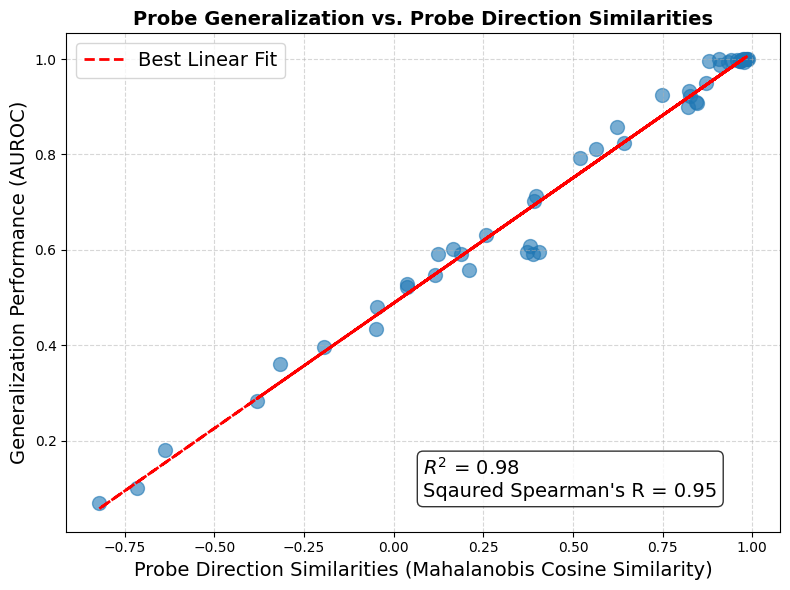

In [15]:
# %%
# === Plot: Mahalanobis Cosine Similarity vs Generalization Gap ===
r2_maha = plot_transfer_analysis(
    transfer_results['maha_cos_sim'],
    transfer_results['auroc_ood'],
    "Probe Direction Similarities (Mahalanobis Cosine Similarity)",
    "Probe Generalization vs. Probe Direction Similarities",
    plot_fit=True
)
# plt.savefig(f"./plots/maha_cossim_vs_auroc_diff.pdf", dpi=300)
plt.show()

/tmp/ipykernel_128985/2706965029.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


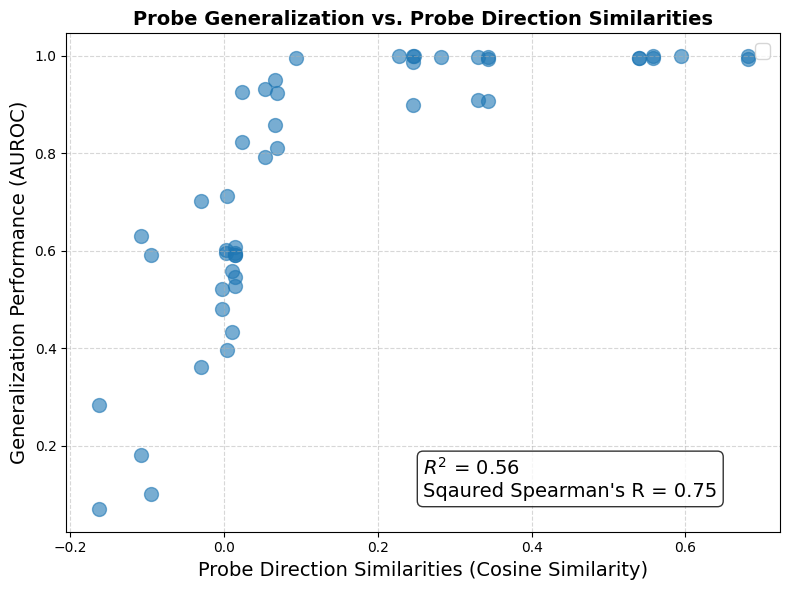

In [17]:
# %%
# === Plot: Standard Cosine Similarity vs Generalization Gap ===
r2_std = plot_transfer_analysis(
    transfer_results['standard_cos_sim'],
    transfer_results['auroc_ood'],
    "Probe Direction Similarities (Cosine Similarity)",
    "Probe Generalization vs. Probe Direction Similarities"
)
plt.show()

### is class-conditioned distribution projected onto probe directions Gaussian after whitening?

In [19]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def compute_kurtosis_torch(tensor_data):
    """Helper to compute Fisher kurtosis on a 1D tensor."""
    if len(tensor_data) == 0:
        return float('nan')
    mean_val = torch.mean(tensor_data)
    m4 = torch.mean((tensor_data - mean_val)**4)
    m2 = torch.mean((tensor_data - mean_val)**2)
    k = (m4 / (m2**2)) - 3.0
    return k.item()

def compute_snr(X, y, covar, w, reg=1e-6):
    """
    Computes SNR for a given direction w, and also computes the SNR 
    for the optimal LDA direction.
    """
    # 1. Calculate Class Means
    mu_pos = X[y == 1].mean(dim=0)
    mu_neg = X[y == 0].mean(dim=0)
    diff_means = mu_pos - mu_neg
    
    # Helper: Logic to calculate SNR for any vector v
    def get_snr_for_direction(v):
        # Flatten to ensure 1D dot product behavior
        numerator = torch.dot(v, diff_means.flatten())
        
        sigma_v = torch.matmul(covar, v)
        v_sigma_v = torch.dot(v, sigma_v)
        
        # Clamp to avoid negative values inside sqrt due to numerical noise
        denominator = torch.sqrt(torch.clamp(v_sigma_v, min=0))
        
        return numerator / (denominator + 1e-8)

    # 2. Compute SNR for the input direction w
    snr_w = get_snr_for_direction(w)
    
    # 3. Compute Optimal LDA Direction
    # Formula: w_lda = Sigma^-1 * (mu_pos - mu_neg)
    # We use linalg.solve(A, b) which solves Ax = b, equivalent to x = A^-1 b.
    # We add a small regularization term (reg) to the diagonal to prevent 
    # crashes if covar is singular.
    covar_reg = covar + torch.eye(covar.shape[0], device=covar.device) * reg
    w_lda = torch.linalg.solve(covar_reg, diff_means)
    w_lda = w_lda / torch.norm(w_lda)
    
    # 4. Compute SNR for the LDA direction (the theoretical maximum)
    snr_opt = get_snr_for_direction(w_lda)

    return snr_w, snr_opt

def compute_within_class_covariance(X, y):
    """Compute pooled within-class covariance."""
    X_pos = X[y == 1]
    X_neg = X[y == 0]
    
    # Center each class
    X_pos_centered = X_pos - X_pos.mean(dim=0)
    X_neg_centered = X_neg - X_neg.mean(dim=0)
    
    # Pool centered data
    X_centered = torch.cat([X_pos_centered, X_neg_centered], dim=0)
    
    # Compute covariance of pooled centered data
    n = X_centered.shape[0]
    covar_within = (X_centered.T @ X_centered) / (n - 2)  # -2 for two class means
    
    return covar_within

def analyze_distribution_torch(X_np, y_np, covar_np, probe_np, task_name="Task", plot=False):
    """
    Analyzes the distribution of data projected onto the probe direction
    AFTER applying Mahalanobis whitening (decorrelation).
    
    Uses score-preserving transformation:
      - Data:  z = Σ^(-1/2) x
      - Probe: w̃ = Σ^(1/2) w
    This ensures w̃^T z = w^T x (original scores preserved).
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 1. Transfer Data to Device
    X = torch.as_tensor(X_np, dtype=torch.float32, device=device)
    y = torch.as_tensor(y_np, device=device)
    probe = torch.as_tensor(probe_np, dtype=torch.float32, device=device)
    covar = torch.as_tensor(covar_np, dtype=torch.float32, device=device)

    covar_within = compute_within_class_covariance(X, y)
    snr, snr_opt = compute_snr(X, y, covar_within, probe)
    # snr = compute_snr(X, y, covar, probe)
    
    if probe.ndim == 1:
        probe = probe.unsqueeze(1)

    # 2. Compute Both Matrix Square Roots via Eigen-decomposition
    dim = covar.shape[0]
    epsilon = 1e-6 * torch.eye(dim, device=device)
    
    eigenvalues, eigenvectors = torch.linalg.eigh(covar + epsilon)
    eig_clamped = torch.maximum(eigenvalues, torch.tensor(1e-10, device=device))
    
    # W_inv_sqrt = Σ^(-1/2) for whitening data
    inv_sqrt_eig = torch.diag(1.0 / torch.sqrt(eig_clamped))
    W_inv_sqrt = eigenvectors @ inv_sqrt_eig @ eigenvectors.T
    
    # W_sqrt = Σ^(1/2) for transforming probes (score-preserving)
    sqrt_eig = torch.diag(torch.sqrt(eig_clamped))
    W_sqrt = eigenvectors @ sqrt_eig @ eigenvectors.T
    
    # 3. Apply Score-Preserving Transformations
    X_whitened = X @ W_inv_sqrt          # z = Σ^(-1/2) x
    probe_whitened = W_sqrt @ probe      # w̃ = Σ^(1/2) w
    
    # 4. Project (scores are preserved: w̃^T z = w^T x)
    scores = X_whitened @ probe_whitened
    scores = scores.squeeze()

    # 5. Split by Class
    scores_pos = scores[y == 1]
    scores_neg = scores[y == 0]

    # --- Compute Stats ---
    mu_pos = scores_pos.mean()
    mu_neg = scores_neg.mean()
    std_pos = scores_pos.std()
    std_neg = scores_neg.std()

    # 6. Normalize scores (Z-score) for Kurtosis Analysis
    scores_pos_norm = (scores_pos - mu_pos) / std_pos
    scores_neg_norm = (scores_neg - mu_neg) / std_neg

    residuals_combined = torch.cat([scores_pos_norm, scores_neg_norm])

    # 7. Measure Kurtosis (Fisher)
    k_pos = compute_kurtosis_torch(scores_pos_norm)
    k_neg = compute_kurtosis_torch(scores_neg_norm)
    k_comb = compute_kurtosis_torch(residuals_combined)

    print(f"--- Mahalanobis Analysis for {task_name} ---")
    print(f"SNR                   : {snr:.4f}")
    print(f"Kurtosis (Class 1)    : {k_pos:.4f}")
    print(f"Kurtosis (Class 0)    : {k_neg:.4f}")
    print(f"Kurtosis (Combined)   : {k_comb:.4f}")
    
    if k_comb < 0.5:
        print("Verdict: Likely GAUSSIAN")
    elif k_comb < 2.0:
        print("Verdict: Moderately LEPTOKURTIC")
    else:
        print("Verdict: Highly LEPTOKURTIC (Heavy Tailed)")

    # 8. Visualization
    if plot:
        res_pos_np = scores_pos_norm.cpu().numpy()
        res_neg_np = scores_neg_norm.cpu().numpy()
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        
        # --- Left Panel: Distribution (KDE) ---
        ax_kde = axes[0]
        sns.kdeplot(res_pos_np, label=f'Class 1 (k={k_pos:.2f})', fill=True, color='blue', alpha=0.2, bw_adjust=1.5, ax=ax_kde)
        sns.kdeplot(res_neg_np, label=f'Class 0 (k={k_neg:.2f})', fill=True, color='orange', alpha=0.2, bw_adjust=1.5, ax=ax_kde)
        
        x = np.linspace(-5, 5, 100)
        ax_kde.plot(x, stats.norm.pdf(x), 'r--', label='Standard Normal (k=0)', linewidth=2)
        
        ax_kde.set_title(f"Distribution: {task_name}\nSNR={snr:.2f} | Combined Kurtosis k={k_comb:.2f}")
        ax_kde.set_xlabel("Standardized Whitened Score")
        ax_kde.legend()
        ax_kde.grid(True, alpha=0.3)

        # --- Right Panel: Q-Q Plot ---
        ax_qq = axes[1]
        
        (osm_pos, osr_pos), _ = stats.probplot(res_pos_np, dist="norm", plot=None)
        ax_qq.scatter(osm_pos, osr_pos, color='blue', alpha=0.6, s=15, label='Class 1')

        (osm_neg, osr_neg), _ = stats.probplot(res_neg_np, dist="norm", plot=None)
        ax_qq.scatter(osm_neg, osr_neg, color='orange', alpha=0.6, s=15, label='Class 0')

        min_val = min(np.min(osm_pos), np.min(osm_neg)) - 0.5
        max_val = max(np.max(osm_pos), np.max(osm_neg)) + 0.5
        ax_qq.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Normal Reference')

        ax_qq.set_title(f"Q-Q Plot: {task_name}")
        ax_qq.set_xlabel("Theoretical Quantiles")
        ax_qq.set_ylabel("Sample Quantiles")
        ax_qq.legend()
        ax_qq.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return snr, snr_opt

# --- USAGE LOOP (Unchanged) ---
if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")

Using GPU: NVIDIA A40


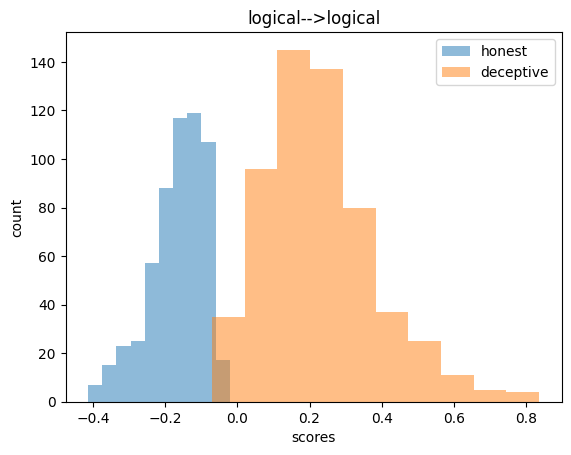

In [44]:
for test_task in TEST_SETTINGS:
    X_np = data[test_task]['X']
    y_np = data[test_task]['y']
    
    for train_task in TRAIN_SETTINGS:

        
        title = f"{DATASET_DISPLAY_NAMES[train_task]}-->{DATASET_DISPLAY_NAMES[test_task]}"
        print(title)
        probe_direction = get_mean_direction(train_task, trained_probes).squeeze()
        probe_direction = probe_direction / np.linalg.norm(probe_direction)
        _scores = X_np @ probe_direction
        plt.hist(_scores[y_np==0], alpha=0.5, label='honest')
        plt.hist(_scores[y_np==1], alpha=0.5, label='deceptive')
        plt.legend()
        plt.xlabel("scores")
        plt.ylabel("count")
        plt.title(title)
        plt.show()

definitional-->definitional
empirical-->definitional
fictional-->definitional


/tmp/ipykernel_49453/1606994126.py:166: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  transformed_direction = direction / valid_scale


logical-->definitional
ethical-->definitional
exp inverted-->definitional
sycophancy-->definitional
combined-->definitional
definitional-->empirical
empirical-->empirical
fictional-->empirical
logical-->empirical
ethical-->empirical
exp inverted-->empirical
sycophancy-->empirical
combined-->empirical
definitional-->fictional
empirical-->fictional
fictional-->fictional
logical-->fictional
ethical-->fictional
exp inverted-->fictional
sycophancy-->fictional
combined-->fictional
definitional-->logical
empirical-->logical
fictional-->logical
logical-->logical
ethical-->logical
exp inverted-->logical
sycophancy-->logical
combined-->logical
definitional-->ethical
empirical-->ethical
fictional-->ethical
logical-->ethical
ethical-->ethical
exp inverted-->ethical
sycophancy-->ethical
combined-->ethical
definitional-->exp inverted
empirical-->exp inverted
fictional-->exp inverted
logical-->exp inverted
ethical-->exp inverted
exp inverted-->exp inverted
sycophancy-->exp inverted
combined-->exp inv

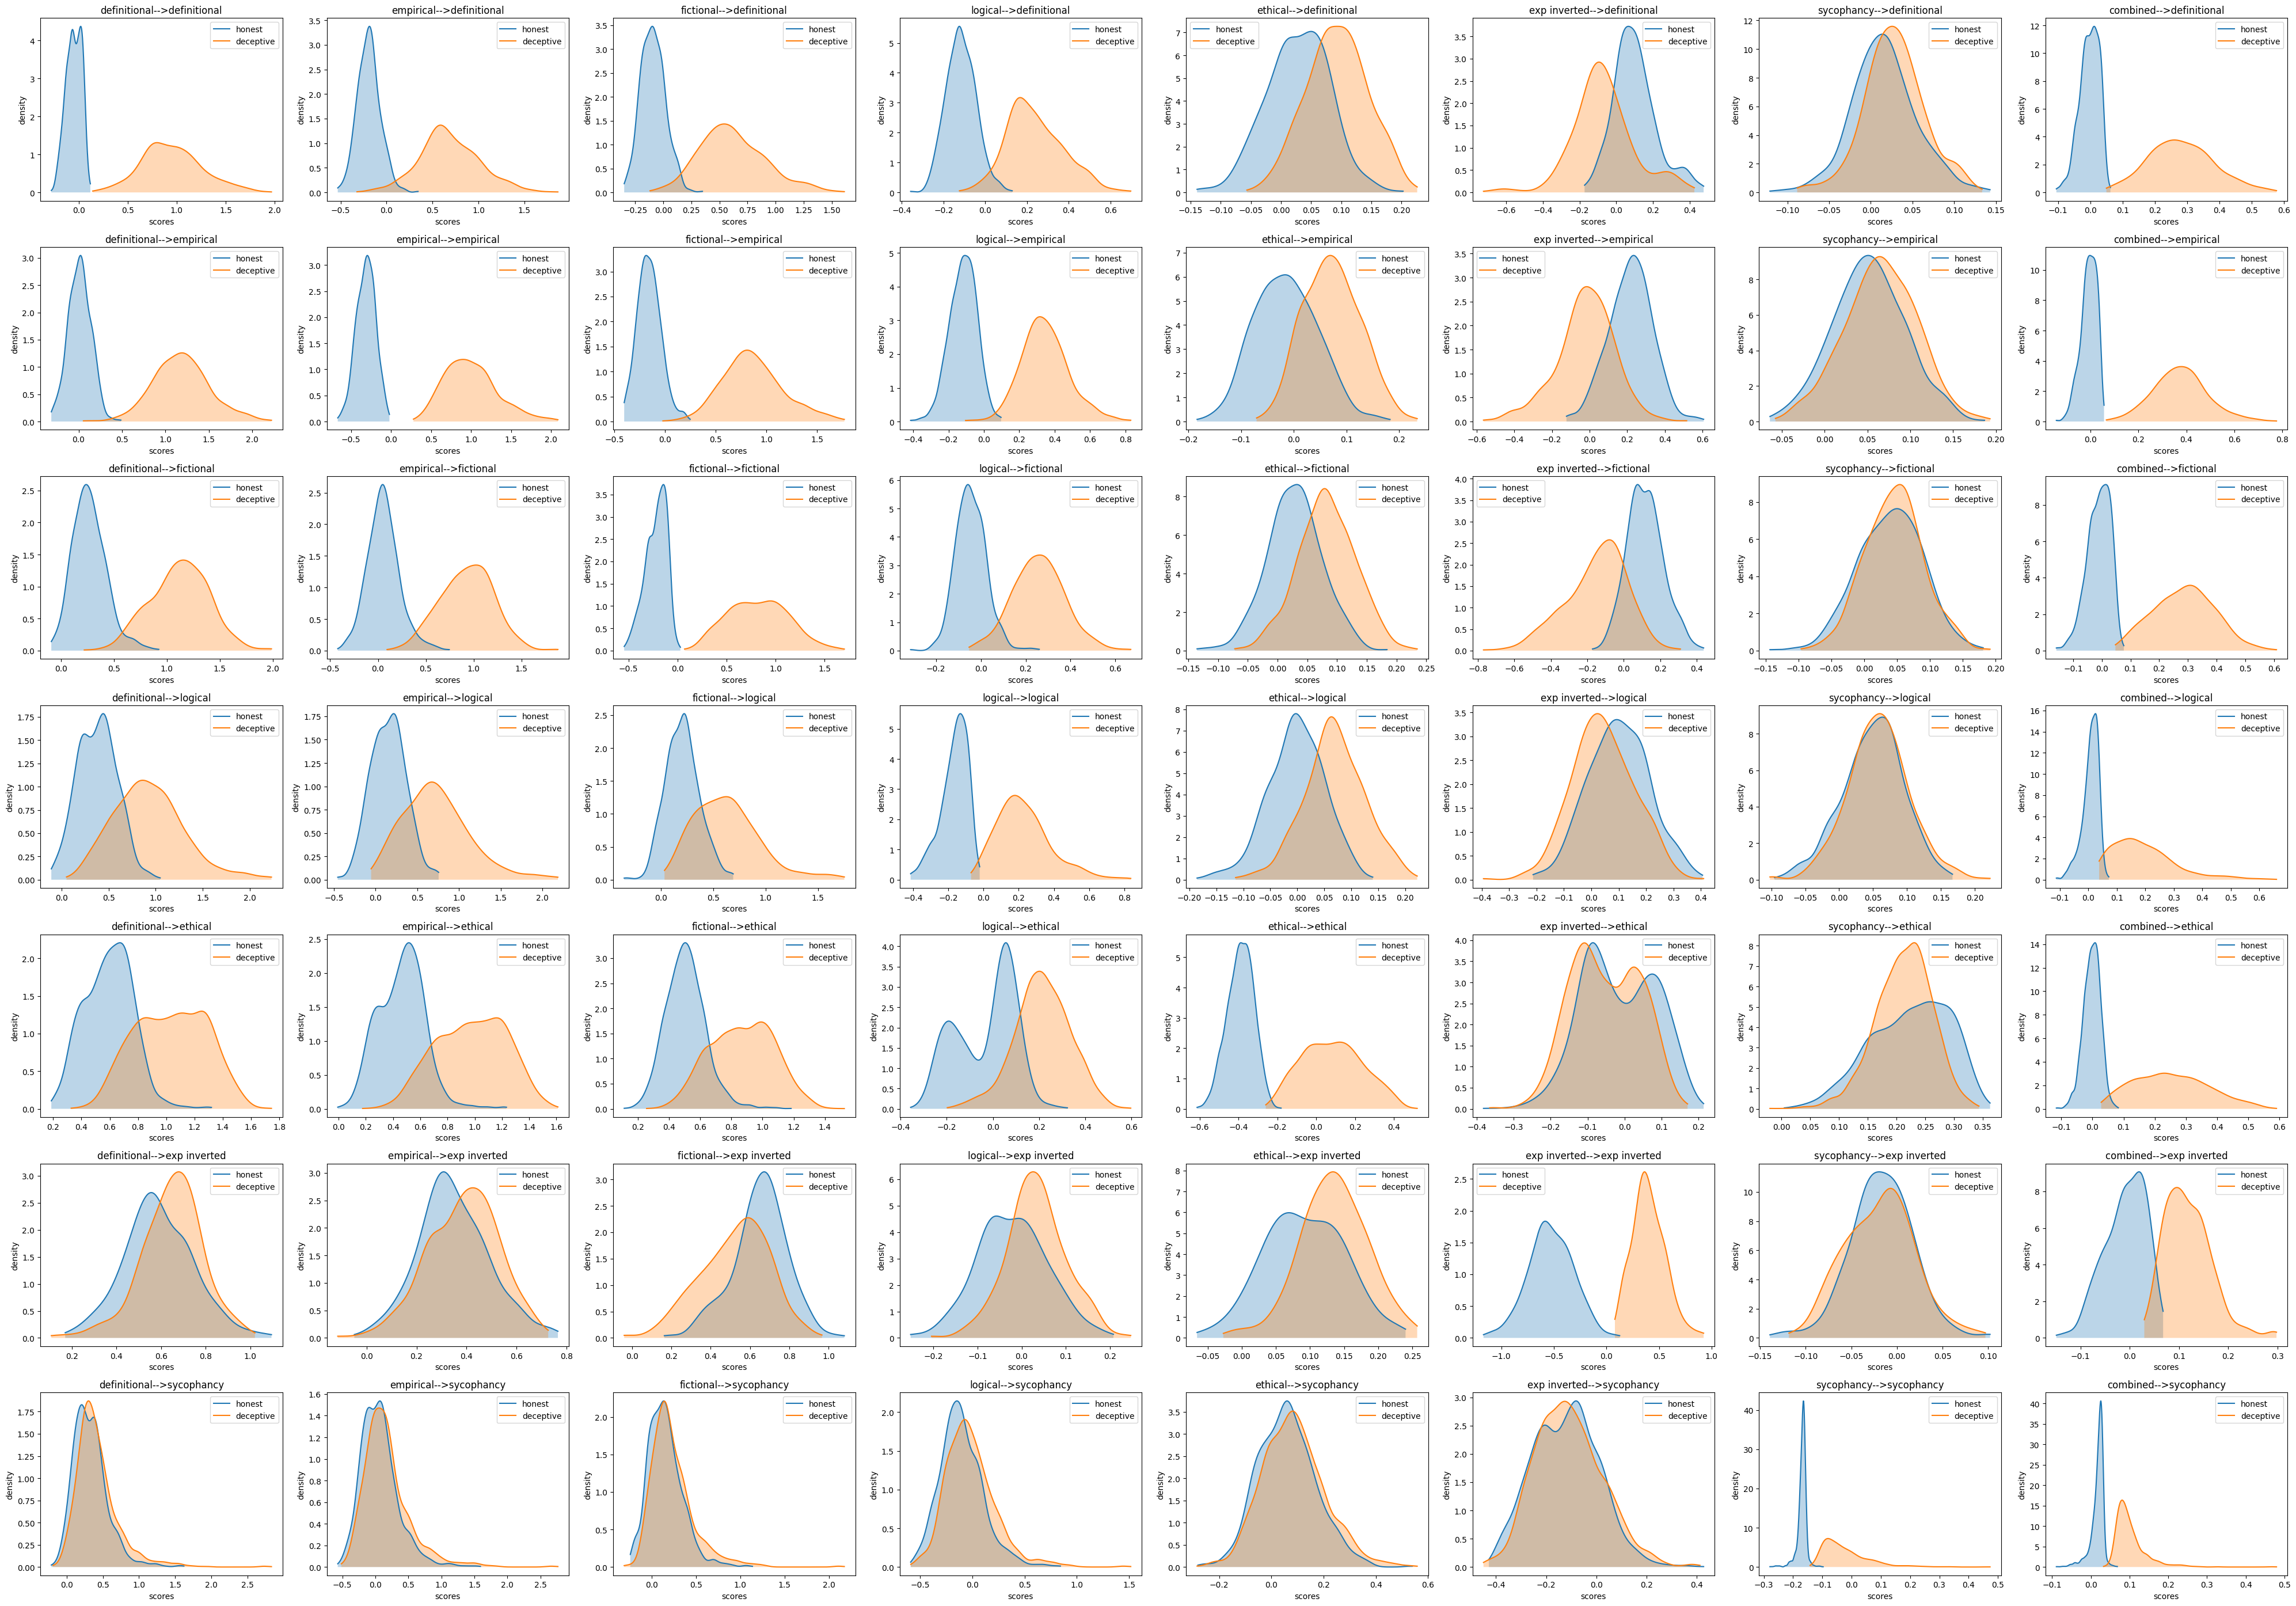

In [53]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(len(TEST_SETTINGS), len(TRAIN_SETTINGS), figsize=(5 * len(TRAIN_SETTINGS), 4 * len(TEST_SETTINGS)), squeeze=False)

for i, test_task in enumerate(TEST_SETTINGS):
    X_np = data[test_task]['X']
    y_np = data[test_task]['y']
    
    for j, train_task in enumerate(TRAIN_SETTINGS):
        ax = axes[i, j]
        title = f"{DATASET_DISPLAY_NAMES[train_task]}-->{DATASET_DISPLAY_NAMES[test_task]}"
        probe_direction = get_mean_direction(train_task, trained_probes).squeeze()
        probe_direction = probe_direction / np.linalg.norm(probe_direction)
        _scores = X_np @ probe_direction
        
        for label_val, label_name in [(0, 'honest'), (1, 'deceptive')]:
            subset = _scores[y_np == label_val]
            kde = gaussian_kde(subset)
            x_grid = np.linspace(subset.min(), subset.max(), 300)
            ax.plot(x_grid, kde(x_grid), label=label_name)
            ax.fill_between(x_grid, kde(x_grid), alpha=0.3)
        
        ax.legend()
        ax.set_xlabel("scores")
        ax.set_ylabel("density")
        ax.set_title(title)

plt.tight_layout()
plt.show()

logical-->logical


/tmp/ipykernel_49453/1606994126.py:166: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  transformed_direction = direction / valid_scale


--- Mahalanobis Analysis for logical-->logical ---
SNR                   : 3.2396
Kurtosis (Class 1)    : 1.0405
Kurtosis (Class 0)    : 0.3501
Kurtosis (Combined)   : 0.6953
Verdict: Moderately LEPTOKURTIC


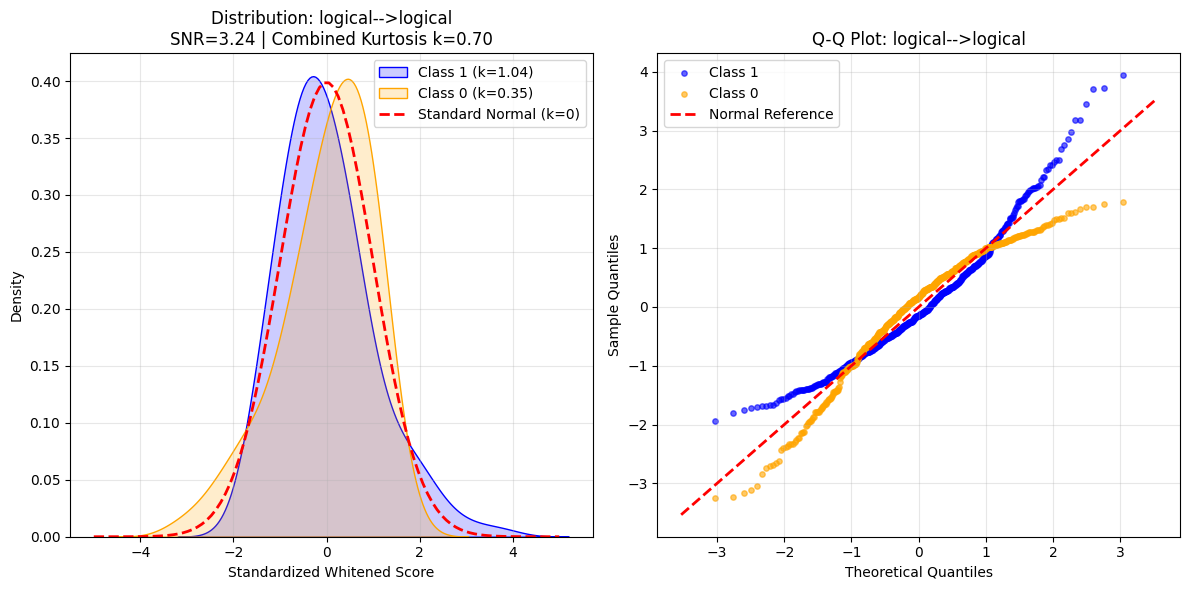

In [43]:
# test_task = 'sycophancy__mmlu_stem_same_conf_all'
# train_task = 'sycophancy__mmlu_stem_same_conf_all'

test_task = 'claims__logical_gemini_600_full'
train_task = 'claims__logical_gemini_600_full'
X_np = data[test_task]['X']
y_np = data[test_task]['y']
covar_np = data[test_task]['covar']
    
title = f"{DATASET_DISPLAY_NAMES[train_task]}-->{DATASET_DISPLAY_NAMES[test_task]}"
print(title)
probe_direction = get_mean_direction(train_task, trained_probes).squeeze()
probe_direction = probe_direction / np.linalg.norm(probe_direction)

snr, snr_opt = analyze_distribution_torch(X_np, y_np, covar_np, probe_direction, task_name=title, plot=True)

### effective dimensionality

In [17]:
## 9. Effective Dimensionality Analysis
def compute_effective_dimensionality(X):
    """
    Compute effective dimensionality using Participation Ratio.
    
    The participation ratio measures how many dimensions contribute
    significantly to the variance in the data.
    
    Args:
        X: Data matrix of shape (n_samples, n_features)
        
    Returns:
        Effective dimensionality (float)
    """
    X_scaled = StandardScaler().fit_transform(X)
    
    pca = PCA()
    pca.fit(X_scaled)
    
    # Get eigenvalues (explained variance)
    eigenvalues = pca.explained_variance_
    
    # Compute Effective Dimensionality (Participation Ratio)
    effective_dim = (np.sum(eigenvalues)**2) / np.sum(eigenvalues**2)
    
    return effective_dim

# === Compute Effective Dimensionality for All Tasks ===
print("=== Effective Dimensionality by Task ===")
print("-" * 40)

effective_dims = {}
for task_name in TRAIN_SETTINGS:
    X = data[task_name]['X']
    eff_dim = compute_effective_dimensionality(X)
    effective_dims[task_name] = eff_dim
    display_name = DATASET_DISPLAY_NAMES.get(task_name, task_name)
    print(f"{display_name:25s}: {eff_dim:.1f}")

# logical: 42, definitional: 54, evidential: 95, fictional: 137
# ethical: 13, sycophancy: 52, exp inverted: 50
# combined: 16????

=== Effective Dimensionality by Task ===
----------------------------------------
definitional             : 54.6
empirical                : 95.4
fictional                : 137.7
logical                  : 42.1
ethical                  : 13.5
sycophancy               : 52.3
exp inverted             : 50.5
combined                 : 16.4


In [121]:
import torch
import torch.nn as nn
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import roc_auc_score

class CORAL_Adapter(nn.Module):
    def __init__(self, feature_dim, momentum=0.1):
        super().__init__()
        self.feature_dim = feature_dim
        self.momentum = momentum
        
        # ID Statistics (Target Geometry)
        self.register_buffer('mu_id', torch.zeros(feature_dim))
        self.register_buffer('cov_id', torch.eye(feature_dim))
        
        # Running Test Statistics (Source Geometry)
        # We use running stats to avoid "Label Shift" issues in small batches
        self.register_buffer('mu_test_running', torch.zeros(feature_dim))
        self.register_buffer('cov_test_running', torch.eye(feature_dim))

    def compute_cov(self, x, mu):
        batch_size = x.size(0)
        x_centered = x - mu
        return (x_centered.t() @ x_centered) / (batch_size - 1)

    def fit_id(self, x_id):
        """Capture the 'Gold Standard' geometry from ID data."""
        with torch.no_grad():
            self.mu_id = x_id.mean(dim=0)
            self.cov_id = self.compute_cov(x_id, self.mu_id)
            
            # Initialize running test stats to ID stats (safe start)
            self.mu_test_running.copy_(self.mu_id)
            self.cov_test_running.copy_(self.cov_id)

    def adapt_and_align(self, x_test):
        """
        CORAL: Align x_test distribution to match mu_id and cov_id.
        Formula: x_aligned = (x_test - mu_test) @ (cov_test^-1/2) @ (cov_id^1/2) + mu_id
        """
        batch_size = x_test.size(0)
        
        # 1. Update Running Statistics (Mitigates Label Shift)
        mu_batch = x_test.mean(dim=0)
        cov_batch = self.compute_cov(x_test, mu_batch)
        
        self.mu_test_running = (1 - self.momentum) * self.mu_test_running + self.momentum * mu_batch
        self.cov_test_running = (1 - self.momentum) * self.cov_test_running + self.momentum * cov_batch
        
        # 2. Compute Whitening Matrix for Test Data (Remove Test Geometry)
        # Sigma_Test^{-1/2}
        vals_test, vecs_test = torch.linalg.eigh(self.cov_test_running + 1e-5 * torch.eye(self.feature_dim, device=x_test.device))
        vals_test = torch.clamp(vals_test, min=1e-8)
        inv_sqrt_test = vecs_test @ torch.diag(1.0 / torch.sqrt(vals_test)) @ vecs_test.t()
        
        # 3. Compute Coloring Matrix for ID Data (Apply ID Geometry)
        # Sigma_ID^{1/2}
        vals_id, vecs_id = torch.linalg.eigh(self.cov_id + 1e-5 * torch.eye(self.feature_dim, device=x_test.device))
        vals_id = torch.clamp(vals_id, min=1e-8)
        sqrt_id = vecs_id @ torch.diag(torch.sqrt(vals_id)) @ vecs_id.t()
        
        # 4. The Transformation: Whiten Test -> Color with ID
        # x_white = (x - mu_test) @ inv_sqrt_test
        # x_aligned = x_white @ sqrt_id + mu_id
        
        correlation_alignment_matrix = inv_sqrt_test @ sqrt_id
        
        return (x_test - self.mu_test_running) @ correlation_alignment_matrix + self.mu_id

class CORAL_Probe_Sklearn:
    def __init__(self, feature_dim):
        self.adapter = CORAL_Adapter(feature_dim)
        self.device = torch.device('cpu')
        
        # Use Standard Solver
        self.classifier = SGDClassifier(loss='log_loss', random_state=42)
        
    def fit(self, x_train, y_train):
        self.device = x_train.device
        self.adapter.to(self.device)
        
        # 1. Learn ID Geometry
        self.adapter.fit_id(x_train)
        
        # 2. Train classifier on RAW ID data (Since we align OOD -> ID)
        X_np = x_train.cpu().numpy()
        y_np = y_train.cpu().numpy() if isinstance(y_train, torch.Tensor) else y_train
        self.classifier.fit(X_np, y_np)
            
    def predict_proba(self, x_test):
        with torch.no_grad():
            if x_test.device != self.device:
                x_test = x_test.to(self.device)
            
            # ALIGN OOD TO ID GEOMETRY
            x_aligned = self.adapter.adapt_and_align(x_test)
            
            X_np = x_aligned.cpu().numpy()
            probs = self.classifier.predict_proba(X_np)[:, 1]
            return torch.tensor(probs).to(self.device)

In [123]:
# --- 1. Synthetic Data Generation ---
torch.manual_seed(42)

train_task = 'claims__definitional_gemini_600_full'
test_task = 'ethics__commonsense'

# ID Data: Standard Gaussian clusters
x_id = torch.tensor(data[train_task]['X'], dtype=torch.float32).cuda()
y_id = torch.tensor(data[train_task]['y'], dtype=torch.long).cuda() # Simple linear boundary on dim 0

# OOD Data: Shifted and Rotated Geometry
# We stretch the data and rotate it, ruining Euclidean distance
x_ood = torch.tensor(data[test_task]['X'], dtype=torch.float32).cuda()
y_ood = torch.tensor(data[test_task]['y'], dtype=torch.long).cuda()

# --- 2. Train MWP ---
model = CORAL_Probe_Sklearn(feature_dim=8192)
model.fit(x_id, y_id)

# --- 3. Evaluate ---

# probs_fail = model.predict_proba(x_ood, tta=False)
# auroc_fail = roc_auc_score(y_ood.cpu().numpy(), probs_fail.cpu().numpy())

# Method: MWP (With TTA)
probs_mwp = model.predict_proba(x_ood)
auroc_mwp = roc_auc_score(y_ood.cpu().numpy(), probs_mwp.cpu().numpy())

print(f"MWP (TTA) AUROC:      {auroc_mwp:.4f}")

MWP (TTA) AUROC:      0.8894


In [129]:
probs = model.classifier.predict_proba(x_ood.cpu().numpy())[:, 1]

In [130]:
roc_auc_score(y_ood.cpu().numpy(), probs)

0.9033415